# New York median income

**Source:** ACS 1-year median household income (Census table B19013), ingested by the
`census-acs-profile` dataset into the `demographics` table (columns `median_household_income`,
`mean_household_income`, `per_capita_income`), currently covering 2010–2023 (no 2020: the Census
Bureau did not publish standard 2020 1-year estimates). Values are in each year's current dollars,
not inflation-adjusted.

The dataset needs `CENSUS_API_KEY`; if the key is missing the first section explains that and the
QCEW section below still shows the closest ingested series (an *average* wage, not a median). To
refresh: `uv run electiondata ingest census-acs-profile -o years=2010,...,2023`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import electiondata as ed
from electiondata.exceptions import DatasetUnavailableError

try:
    acs = ed.demographics.state(state="NY")
except DatasetUnavailableError as exc:
    acs = pd.DataFrame()
    print("ACS not available:", exc)

acs_available = not acs.empty and acs["median_household_income"].notna().any()
print("ACS median household income for New York available:", acs_available)

ACS median household income for New York available: True


## 1. ACS median household income (populates once `census-acs-profile` is ingested)

,year,survey,median_household_income,mean_household_income,per_capita_income,publication_date
0,2010,acs1,54148.0,78726.206894,30011.0,2011-09-30
1,2011,acs1,55246.0,80243.857752,30679.0,2012-09-30
2,2012,acs1,56448.0,81440.750791,31290.0,2013-09-30
3,2013,acs1,57369.0,84973.436633,32514.0,2014-09-30
4,2014,acs1,58878.0,86563.196848,33095.0,2015-09-30
5,2015,acs1,60850.0,89907.953972,34297.0,2016-09-30
6,2016,acs1,62909.0,93373.301157,35534.0,2017-09-30
7,2017,acs1,64894.0,97115.685391,37156.0,2018-09-30
8,2018,acs1,67844.0,100421.940338,38884.0,2019-09-30
9,2019,acs1,72108.0,107355.066786,41857.0,2020-09-30


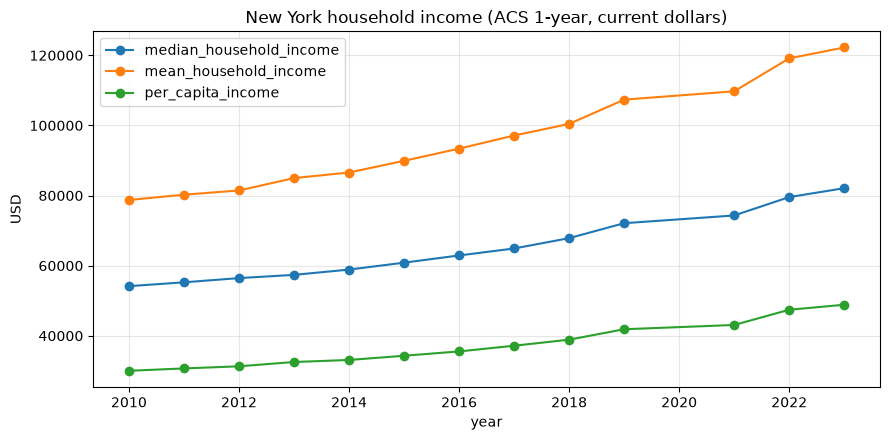

In [2]:
if acs_available:
    inc = acs.sort_values("year")[["year", "survey", "median_household_income", "mean_household_income",
                                   "per_capita_income", "publication_date"]].reset_index(drop=True)
    display(inc)
    ax = inc.set_index("year")[["median_household_income", "mean_household_income", "per_capita_income"]].plot(
        marker="o", figsize=(9, 4.5))
    ax.set_title("New York household income (ACS 1-year, current dollars)")
    ax.set_ylabel("USD")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No ACS rows: median household income cannot be shown. Set CENSUS_API_KEY and ingest census-acs-profile.")

## 2. Fallback: average annual pay per covered job (BLS QCEW)

This is the **average** wage per job across all covered employment in New York (QCEW `avg_annual_pay`,
industry code 10, all ownerships). It is *not* a median and *not* household income — it is shown only
because it is the income-like series currently in the store. Only the years ingested so far appear
(`electiondata ingest bls-qcew -o years=...` adds more).

,year,avg_annual_pay,annual_avg_weekly_wage,annual_avg_employment,publication_date
0,2023,91428.0,1758.0,9471806.0,2024-06-30
1,2024,95082.0,1829.0,9705821.0,2025-06-30


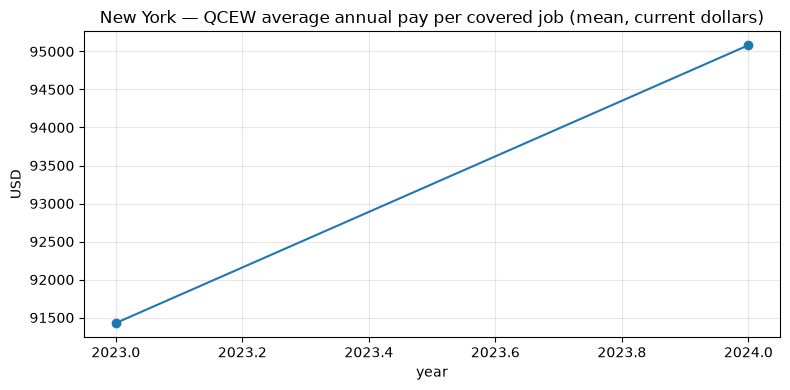

In [3]:
ind = ed.economics.industry(state="NY")
tot = (ind[(ind["industry_code"] == "10") & (ind["own_code"] == "0")]
       .sort_values("year")[["year", "avg_annual_pay", "annual_avg_weekly_wage", "annual_avg_employment", "publication_date"]]
       .reset_index(drop=True))
display(tot)
ax = tot.set_index("year")["avg_annual_pay"].plot(marker="o", figsize=(8, 4))
ax.set_title("New York — QCEW average annual pay per covered job (mean, current dollars)")
ax.set_ylabel("USD")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Point-in-time view

For modelling, use `as_of` so only values published by the forecast date are used, e.g. the ACS
figure available on 15 Oct 2024 is the 2023 estimate (released September 2024):

In [4]:
snap = ed.demographics.snapshot("2000-10-15", state="NY")
cols = [c for c in ("acs_year", "median_household_income", "per_capita_income", "population_year", "population") if c in snap.columns]
snap[["state", *cols]]

,state,median_household_income,per_capita_income
